# Dataset and hierarchy analysis

This notebook characterizes the three datasets used in the thesis experiments: **CIFAR-100**, **CUB-200-2011**, and **FGVC-Aircraft**. It reads the same configuration files and dataset adapters used during training, ensuring that split sizes, label IDs, and hierarchy edges match the corrected unified experimental protocol.

The analysis addresses four questions relevant to the experiments chapter:

1. How much data is available at each split and hierarchy level?
2. How balanced are the sample distributions and the hierarchy itself?
3. How do image scale and aspect ratio differ across datasets?
4. Which hierarchy properties may affect optimization and evaluation?

> **Hierarchy provenance.** CIFAR-100 combines the official 20 coarse and 100 fine labels with the published B-CNN 8-class upper edge. CUB uses the 13-order/38-family/200-species mapping retained from H-CAST. Aircraft reconstructs the official 30-manufacturer/70-family/100-variant hierarchy by joining the parallel official annotations. These are experimental taxonomies: their different provenance should be stated explicitly in the thesis.


In [1]:
from collections import Counter
from pathlib import Path
import os
import pickle
import sys
import textwrap

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from omegaconf import OmegaConf
from PIL import Image

# Work from either the repository root or analysis/.
cwd = Path.cwd().resolve()
REPO_ROOT = next((p for p in [cwd, *cwd.parents] if (p / 'configs').is_dir() and (p / 'datasets').is_dir()), None)
if REPO_ROOT is None:
    raise RuntimeError('Run this notebook from the repository or one of its subdirectories.')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from datasets.aircraft import AircraftDataset
from datasets.cifar100 import CIFAR100Dataset
from datasets.cub import CUBDataset

# Figures are authored at their final printed width and must be included with
# width=\linewidth and no extra scaling: any additional resizing in LaTeX shrinks
# the font sizes set below along with the artwork.
TEXT_WIDTH_IN = 6.3   # A4 text block with 2.5 cm margins
HALF_WIDTH_IN = 3.05

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 140, 'savefig.dpi': 400,
    'font.family': 'serif', 'font.serif': ['DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'font.size': 9, 'axes.titlesize': 9, 'axes.labelsize': 8.5,
    'xtick.labelsize': 7.5, 'ytick.labelsize': 7.5,
    'legend.fontsize': 7, 'legend.title_fontsize': 7,
    'axes.axisbelow': True, 'grid.linewidth': 0.5,
    'pdf.fonttype': 42, 'ps.fonttype': 42,
    'figure.constrained_layout.use': True,
})

# One palette per semantic axis, so a hue never carries two meanings in one figure:
# datasets and splits use Okabe-Ito hues, hierarchy levels an ordered purple ramp.
COLORS = {'CIFAR-100': '#0072B2', 'CUB-200-2011': '#009E73', 'FGVC-Aircraft': '#D55E00'}
SPLIT_COLORS = {'train': '#0072B2', 'val': '#E69F00', 'test': '#009E73'}
LEVEL_COLORS = ['#CBC0DD', '#8C6BB1', '#4D004B']
TRANSITION_COLORS = ['#9E9AC8', '#54278F']
LEVEL_EDGE = '#3F1F52'
SHORT_NAMES = {'CIFAR-100': 'CIFAR-100', 'CUB-200-2011': 'CUB-200', 'FGVC-Aircraft': 'Aircraft'}
MODEL_INPUT_PX = 224  # reference input resolution of the model presets
print(f'Repository: {REPO_ROOT}')


Repository: /home/g.saggini1/lexicographic_deep_learning_detailed_study


/home/g.saggini1/lexicographic_deep_learning_detailed_study/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

Dataset roots follow the same environment variables as training (`CIFAR100_ROOT`, `CUB200_ROOT`, and `AIRCRAFT_ROOT`). Figures and tables are external runtime artifacts and are therefore written below `/scratch/g.saggini1/outputs` by default. Set `DATASET_ANALYSIS_OUTPUT` to override that location. Image geometry is sampled deterministically to keep reruns fast; increase `MAX_IMAGES_PER_SPLIT` for an exhaustive scan.

Every figure is produced at its final printed size through `save_figure`, which writes a PDF and a PNG without `bbox_inches='tight'`. Cropping would change the physical width of the file and therefore the apparent font size once the figure is placed in the thesis, so the figures must be included at `\linewidth` with no further scaling.


In [2]:
OUTPUT_DIR = Path(os.environ.get(
    'DATASET_ANALYSIS_OUTPUT',
    '/scratch/g.saggini1/outputs/analysis/datasets',
)).expanduser()
FIGURE_DIR = OUTPUT_DIR / 'figures'
TABLE_DIR = OUTPUT_DIR / 'tables'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
MAX_IMAGES_PER_SPLIT = 2_000
RANDOM_SEED = 2026


def save_figure(fig, stem, formats=('pdf', 'png')):
    """Write a figure at its authored size.

    ``bbox_inches='tight'`` is deliberately not used: it re-crops the canvas and
    changes the physical width, which would break the one-to-one relationship
    between the authored figure size and the printed text width.
    """
    for suffix in formats:
        fig.savefig(FIGURE_DIR / f'{stem}.{suffix}')


DATASET_SPECS = {
    'CIFAR-100': {
        'config': REPO_ROOT / 'configs/hcast/hcast_cifar100.yaml',
        'adapter': CIFAR100Dataset,
        'provenance': 'official fine/coarse labels + published B-CNN upper edge',
    },
    'CUB-200-2011': {
        'config': REPO_ROOT / 'configs/hcast/hcast_cub200.yaml',
        'adapter': CUBDataset,
        'provenance': 'official images/split + order/family mapping retained from H-CAST',
    },
    'FGVC-Aircraft': {
        'config': REPO_ROOT / 'configs/hcast/hcast_aircraft.yaml',
        'adapter': AircraftDataset,
        'provenance': 'official parallel manufacturer/family/variant annotations',
    },
}
print(f'Exports: {OUTPUT_DIR}')


Exports: /scratch/g.saggini1/outputs/analysis/datasets


## Load the experiment datasets

The training split creates the canonical label space. Validation and test then reuse it, exactly as in `datasets.loaders.build_dataloaders`. This prevents split-local remapping and verifies that every child has one consistent parent. No augmentation is applied in this descriptive analysis.


In [3]:
def load_experiment_datasets():
    loaded = {}
    for dataset_name, spec in DATASET_SPECS.items():
        cfg = OmegaConf.load(spec['config'])
        OmegaConf.resolve(cfg)
        adapter = spec['adapter']
        train = adapter(cfg=cfg, split='train', transform=None, label_space=None)
        split_datasets = {'train': train}
        for split in ('val', 'test'):
            split_datasets[split] = adapter(
                cfg=cfg, split=split, transform=None, label_space=train.label_space
            )
        loaded[dataset_name] = {'cfg': cfg, 'splits': split_datasets}
        sizes = ', '.join(f'{s}={len(ds):,}' for s, ds in split_datasets.items())
        print(f'{dataset_name}: {sizes}; classes={train.num_classes_per_level}')
    return loaded

datasets_by_name = load_experiment_datasets()


CIFAR-100: train=45,000, val=5,000, test=10,000; classes=[8, 20, 100]
CUB-200-2011: train=5,194, val=800, test=5,794; classes=[13, 38, 200]
FGVC-Aircraft: train=3,334, val=3,333, test=3,333; classes=[30, 70, 100]


In [4]:
def samples_dataframe(loaded):
    rows = []
    for dataset_name, bundle in loaded.items():
        levels = list(bundle['cfg'].dataset.levels)
        for split, dataset in bundle['splits'].items():
            for index, sample in enumerate(dataset.samples):
                row = {'dataset': dataset_name, 'split': split, 'sample_index': index}
                row.update({level: int(label) for level, label in zip(levels, sample['labels'])})
                rows.append(row)
    return pd.DataFrame(rows)

samples = samples_dataframe(datasets_by_name)
samples.head()


,dataset,split,sample_index,coarse1,coarse2,fine,order,family,species,manufacturer,variant
0,CIFAR-100,train,0,4.0,11.0,19.0,NaN,NaN,NaN,NaN,NaN
1,CIFAR-100,train,1,4.0,15.0,29.0,NaN,NaN,NaN,NaN,NaN
2,CIFAR-100,train,2,1.0,4.0,0.0,NaN,NaN,NaN,NaN,NaN
3,CIFAR-100,train,3,6.0,14.0,11.0,NaN,NaN,NaN,NaN,NaN
4,CIFAR-100,train,4,0.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN


## Dataset scale and label granularity

The table separates the number of images from the number of semantic classes. `Classes (observed)` is split-specific; `Classes (taxonomy)` is the canonical training/authoritative label space used by every split. Samples per class are reported at the leaf level, where visual discrimination is most fine-grained.

**How to read the scale figure.** Panel (a) gives absolute size: each bar is one dataset and its colored segments are the mutually exclusive train, validation, and test splits, so the total bar height is the complete number of images used by the protocol. CIFAR-100 is an order of magnitude larger than the other two, which compresses them; panel (b) therefore repeats the same three splits as percentages of each dataset so that the *protocol asymmetry* stays visible — CIFAR-100 and CUB devote a small fraction to validation, whereas Aircraft inherits an official partition of roughly one third per split. The class counts per level are read from the table above rather than plotted: three numbers per dataset do not need a figure.


In [5]:
def gini(values):
    x = np.asarray(values, dtype=float)
    if x.size == 0 or np.allclose(x.sum(), 0):
        return np.nan
    x = np.sort(x)
    n = x.size
    return float((2 * np.sum((np.arange(1, n + 1)) * x) / (n * x.sum())) - (n + 1) / n)

summary_rows = []
for dataset_name, bundle in datasets_by_name.items():
    levels = list(bundle['cfg'].dataset.levels)
    taxonomy_counts = bundle['splits']['train'].num_classes_per_level
    for split in ('train', 'val', 'test'):
        frame = samples.query('dataset == @dataset_name and split == @split')
        leaf_counts = frame[levels[-1]].value_counts().reindex(range(taxonomy_counts[-1]), fill_value=0)
        row = {
            'Dataset': dataset_name, 'Split': split, 'Images': len(frame),
            'Leaf samples min': int(leaf_counts.min()),
            'Leaf samples median': float(leaf_counts.median()),
            'Leaf samples max': int(leaf_counts.max()),
            'Leaf-count Gini': gini(leaf_counts),
        }
        for level, total in zip(levels, taxonomy_counts):
            row[f'{level} classes (observed)'] = int(frame[level].nunique())
            row[f'{level} classes (taxonomy)'] = int(total)
        summary_rows.append(row)

dataset_summary = pd.DataFrame(summary_rows)
dataset_summary.to_csv(TABLE_DIR / 'dataset_split_summary.csv', index=False)
display(dataset_summary.style.format({'Images': '{:,}', 'Leaf samples median': '{:.1f}', 'Leaf-count Gini': '{:.3f}'}))


,Dataset,Split,Images,Leaf samples min,Leaf samples median,Leaf samples max,Leaf-count Gini,coarse1 classes (observed),coarse1 classes (taxonomy),coarse2 classes (observed),coarse2 classes (taxonomy),fine classes (observed),fine classes (taxonomy),order classes (observed),order classes (taxonomy),family classes (observed),family classes (taxonomy),species classes (observed),species classes (taxonomy),manufacturer classes (observed),manufacturer classes (taxonomy),variant classes (observed),variant classes (taxonomy)
0,CIFAR-100,train,"45,000",450,450.0,450,0.000,8.000000,8.000000,20.000000,20.000000,100.000000,100.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
1,CIFAR-100,val,"5,000",50,50.0,50,0.000,8.000000,8.000000,20.000000,20.000000,100.000000,100.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
2,CIFAR-100,test,"10,000",100,100.0,100,0.000,8.000000,8.000000,20.000000,20.000000,100.000000,100.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
3,CUB-200-2011,train,"5,194",25,26.0,26,0.001,nan,nan,nan,nan,nan,nan,13.000000,13.000000,38.000000,38.000000,200.000000,200.000000,nan,nan,nan,nan
4,CUB-200-2011,val,800,4,4.0,4,0.000,nan,nan,nan,nan,nan,nan,13.000000,13.000000,38.000000,38.000000,200.000000,200.000000,nan,nan,nan,nan
5,CUB-200-2011,test,"5,794",11,30.0,30,0.031,nan,nan,nan,nan,nan,nan,13.000000,13.000000,38.000000,38.000000,200.000000,200.000000,nan,nan,nan,nan
6,FGVC-Aircraft,train,"3,334",33,33.0,34,0.007,nan,nan,nan,nan,nan,nan,nan,nan,70.000000,70.000000,nan,nan,30.000000,30.000000,100.000000,100.000000
7,FGVC-Aircraft,val,"3,333",33,33.0,34,0.007,nan,nan,nan,nan,nan,nan,nan,nan,70.000000,70.000000,nan,nan,30.000000,30.000000,100.000000,100.000000
8,FGVC-Aircraft,test,"3,333",33,33.0,34,0.007,nan,nan,nan,nan,nan,nan,nan,nan,70.000000,70.000000,nan,nan,30.000000,30.000000,100.000000,100.000000


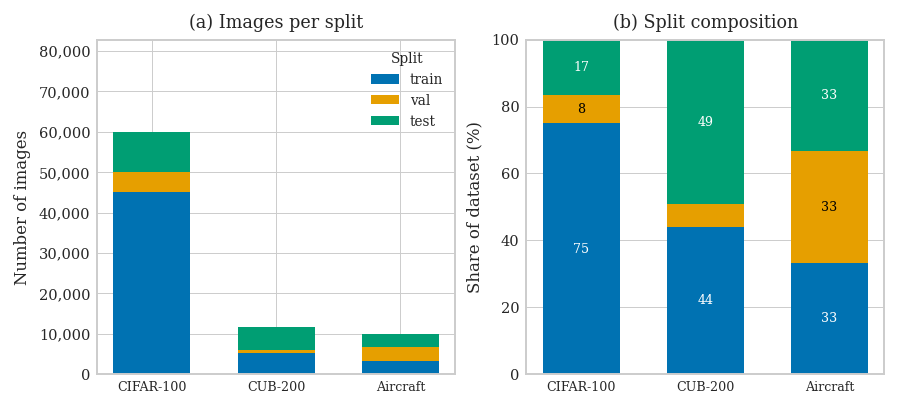

In [6]:
fig, (ax_samples, ax_share) = plt.subplots(1, 2, figsize=(TEXT_WIDTH_IN, 2.8))
dataset_order = list(DATASET_SPECS)
x = np.arange(len(dataset_order))
tick_labels = [SHORT_NAMES[name] for name in dataset_order]
totals = np.array([
    sum(len(datasets_by_name[name]['splits'][split]) for split in ('train', 'val', 'test'))
    for name in dataset_order
], dtype=float)

bottom = np.zeros(len(dataset_order))
bottom_share = np.zeros(len(dataset_order))
for split in ('train', 'val', 'test'):
    values = np.array([len(datasets_by_name[name]['splits'][split]) for name in dataset_order], dtype=float)
    shares = 100.0 * values / totals
    ax_samples.bar(x, values, bottom=bottom, label=split, color=SPLIT_COLORS[split], width=0.62)
    ax_share.bar(x, shares, bottom=bottom_share, label=split, color=SPLIT_COLORS[split], width=0.62)
    for position, (share, base) in enumerate(zip(shares, bottom_share)):
        if share >= 7:
            ax_share.text(position, base + share / 2, f'{share:.0f}', ha='center', va='center',
                          fontsize=6.5, color='black' if split == 'val' else 'white')
    bottom += values
    bottom_share += shares

ax_samples.set_xticks(x, tick_labels)
ax_samples.tick_params(axis='x', labelsize=6.5)
ax_samples.set_ylim(0, totals.max() * 1.38)
ax_samples.set_ylabel('Number of images')
ax_samples.set_title('(a) Images per split')
ax_samples.legend(title='Split', loc='upper right')
ax_samples.yaxis.set_major_formatter(lambda value, _: f'{int(value):,}')

ax_share.set_xticks(x, tick_labels)
ax_share.tick_params(axis='x', labelsize=6.5)
ax_share.set_ylim(0, 100)
ax_share.set_ylabel('Share of dataset (%)')
ax_share.set_title('(b) Split composition')

save_figure(fig, 'dataset_scale_and_taxonomy_width')
plt.show()


## Sample balance and split representativeness

A dataset can be structurally unbalanced even when every leaf class has almost the same number of images, so **sample imbalance** and **hierarchy imbalance** are kept separate: the tables below cover the first, the figures of the next section cover the second.

Sample balance needs no figure here. All three datasets are close to uniform at the leaf level — CIFAR-100 has exactly 450 training images per fine class, Aircraft 33 or 34 per variant, CUB 25 or 26 per species — and the only visible dispersion is the CUB test split, which ranges from 11 to 30 images per species. Any distributional plot of these counts is therefore a near-degenerate line and carries less information than the two tables. What does matter for the experiments chapter is the difference in *support*: a CIFAR-100 leaf class is trained on roughly an order of magnitude more images than a CUB or Aircraft leaf class.

**How to read the tables.** The Gini coefficient and coefficient of variation summarize dispersion: values closer to zero indicate more uniform leaf-class counts. Jensen–Shannon divergence measures how closely validation and test reproduce the training leaf-class distribution; it is reported in bits and lies between 0 and 1 here, and values closer to zero mean that a split preserves the training class proportions more closely.


In [7]:
def leaf_count_vector(dataset_name, split):
    bundle = datasets_by_name[dataset_name]
    leaf = str(bundle['cfg'].dataset.levels[-1])
    n_leaf = bundle['splits']['train'].num_classes_per_level[-1]
    frame = samples.query('dataset == @dataset_name and split == @split')
    return frame[leaf].value_counts().reindex(range(n_leaf), fill_value=0).sort_index().to_numpy()

def js_divergence(counts_a, counts_b):
    p = np.asarray(counts_a, dtype=float)
    q = np.asarray(counts_b, dtype=float)
    p, q = p / p.sum(), q / q.sum()
    m = 0.5 * (p + q)
    def kl(a, b):
        mask = a > 0
        return np.sum(a[mask] * np.log2(a[mask] / b[mask]))
    return float(0.5 * kl(p, m) + 0.5 * kl(q, m))

balance_rows = []
for dataset_name in DATASET_SPECS:
    for split in ('train', 'val', 'test'):
        counts = leaf_count_vector(dataset_name, split)
        balance_rows.append({
            'dataset': dataset_name, 'split': split, 'minimum': int(counts.min()),
            'median': float(np.median(counts)), 'maximum': int(counts.max()),
            'gini': gini(counts),
            'coefficient_of_variation': float(np.std(counts) / np.mean(counts)),
        })

balance_summary = pd.DataFrame(balance_rows)
balance_summary.to_csv(TABLE_DIR / 'leaf_class_balance.csv', index=False)
display(balance_summary.style.format({'median': '{:.1f}', 'gini': '{:.3f}', 'coefficient_of_variation': '{:.3f}'}))

js_rows = []
for dataset_name in DATASET_SPECS:
    train_counts = leaf_count_vector(dataset_name, 'train')
    for split in ('val', 'test'):
        js_rows.append({
            'Dataset': dataset_name, 'Compared with train': split,
            'Jensen-Shannon divergence (bits)': js_divergence(train_counts, leaf_count_vector(dataset_name, split)),
        })
split_representativeness = pd.DataFrame(js_rows)
split_representativeness.to_csv(TABLE_DIR / 'split_representativeness.csv', index=False)
display(split_representativeness.style.format({'Jensen-Shannon divergence (bits)': '{:.5f}'}))


,dataset,split,minimum,median,maximum,gini,coefficient_of_variation
0,CIFAR-100,train,450,450.0,450,0.000,0.000
1,CIFAR-100,val,50,50.0,50,0.000,0.000
2,CIFAR-100,test,100,100.0,100,0.000,0.000
3,CUB-200-2011,train,25,26.0,26,0.001,0.007
4,CUB-200-2011,val,4,4.0,4,0.000,0.000
5,CUB-200-2011,test,11,30.0,30,0.031,0.101
6,FGVC-Aircraft,train,33,33.0,34,0.007,0.014
7,FGVC-Aircraft,val,33,33.0,34,0.007,0.014
8,FGVC-Aircraft,test,33,33.0,34,0.007,0.014


,Dataset,Compared with train,Jensen-Shannon divergence (bits)
0,CIFAR-100,val,0.00000
1,CIFAR-100,test,0.00000
2,CUB-200-2011,val,0.00001
3,CUB-200-2011,test,0.00233
4,FGVC-Aircraft,val,0.00011
5,FGVC-Aircraft,test,0.00011


## Hierarchy structure and imbalance

Four figures describe the taxonomies. **Branching factor is local:** for every parent, it counts only the immediate children at one transition (top→middle or middle→leaf). **Structural imbalance is cumulative:** for every top-level class, it follows both transitions and counts all reachable leaf classes. Two roots can each have two middle-level children and still cover very different numbers of leaves if their middle-level subtrees differ in size, so the cumulative view is not a second reading of the first transition.

**How to read the beeswarm figure.** Every circle is one parent class, and its vertical coordinate is the exact integer number of immediate children. Parents with the same value are packed symmetrically around the transition center, so horizontal displacement visualizes local frequency rather than random jitter. Groups widen as frequency increases, up to a fixed maximum width that prevents overlap with the other transition. The black segment is the median and the white diamond is the mean. A tight vertical cluster indicates similar fan-out; a large vertical spread indicates unequal fan-out. The annotation above each panel counts the parents with a single child, which is the quantity that matters most for hierarchical classification: such a parent is a *relabelling* rather than a decision, because the coarse label already determines the fine one. The preceding table remains the source for exact standard deviations and coefficients of variation.

**How to read the ranked descendant figure.** Each bar is a top-level class, and bar height is the number of leaf classes reachable beneath it through the middle level. Bars are sorted from largest to smallest, so horizontal position is a rank, not a class ID, and positions must not be matched across datasets. A flat profile indicates similarly sized top-level subtrees; a steep profile means that a few coarse classes represent most of the fine-grained alternatives. The largest top-level class is named where the dataset supplies names (Aircraft manufacturers); for CIFAR-100 and CUB the annotation gives the contiguous label-space ID used throughout this notebook, which is not the numbering of the original CUB order list.


In [8]:
def taxonomy_frames(dataset_name, bundle):
    levels = list(bundle['cfg'].dataset.levels)
    taxonomy = bundle['splits']['train'].taxonomy
    counts = bundle['splits']['train'].num_classes_per_level
    edges = []
    branching = []
    for child_level in range(1, len(levels)):
        parent_map = taxonomy['parent_of'][child_level]
        child_counts = Counter(int(parent) for parent in parent_map.values())
        for child, parent in sorted(parent_map.items()):
            edges.append({
                'dataset': dataset_name, 'transition': f'{levels[child_level-1]} → {levels[child_level]}',
                'parent_level': levels[child_level-1], 'child_level': levels[child_level],
                'parent_id': int(parent), 'child_id': int(child),
            })
        for parent in range(counts[child_level - 1]):
            branching.append({
                'dataset': dataset_name, 'transition': f'{levels[child_level-1]} → {levels[child_level]}',
                'parent_id': parent, 'children': child_counts.get(parent, 0),
            })
    return pd.DataFrame(edges), pd.DataFrame(branching)

edge_frames, branching_frames = [], []
for name, bundle in datasets_by_name.items():
    edge_frame, branch_frame = taxonomy_frames(name, bundle)
    edge_frames.append(edge_frame)
    branching_frames.append(branch_frame)
taxonomy_edges = pd.concat(edge_frames, ignore_index=True)
branching = pd.concat(branching_frames, ignore_index=True)
taxonomy_edges.to_csv(TABLE_DIR / 'taxonomy_edges.csv', index=False)
branching.to_csv(TABLE_DIR / 'hierarchy_branching_factors.csv', index=False)

hierarchy_summary = (branching.groupby(['dataset', 'transition'])['children']
    .agg(parents='count', children='sum', minimum='min', median='median', mean='mean', maximum='max', std='std')
    .reset_index())
hierarchy_summary['coefficient_of_variation'] = hierarchy_summary['std'] / hierarchy_summary['mean']
hierarchy_summary['single_child_parents'] = [
    int((branching.query('dataset == @d and transition == @t').children == 1).sum())
    for d, t in hierarchy_summary[['dataset', 'transition']].itertuples(index=False, name=None)
]
hierarchy_summary.to_csv(TABLE_DIR / 'hierarchy_summary.csv', index=False)
display(hierarchy_summary.style.format({'median': '{:.1f}', 'mean': '{:.2f}', 'std': '{:.2f}', 'coefficient_of_variation': '{:.3f}'}))


,dataset,transition,parents,children,minimum,median,mean,maximum,std,coefficient_of_variation,single_child_parents
0,CIFAR-100,coarse1 → coarse2,8,20,1,2.0,2.50,5,1.20,0.478,1
1,CIFAR-100,coarse2 → fine,20,100,5,5.0,5.00,5,0.00,0.000,0
2,CUB-200-2011,family → species,38,200,1,3.5,5.26,30,6.20,1.178,12
3,CUB-200-2011,order → family,13,38,1,1.0,2.92,21,5.47,1.871,8
4,FGVC-Aircraft,family → variant,70,100,1,1.0,1.43,8,1.08,0.759,54
5,FGVC-Aircraft,manufacturer → family,30,70,1,2.0,2.33,8,1.81,0.774,14


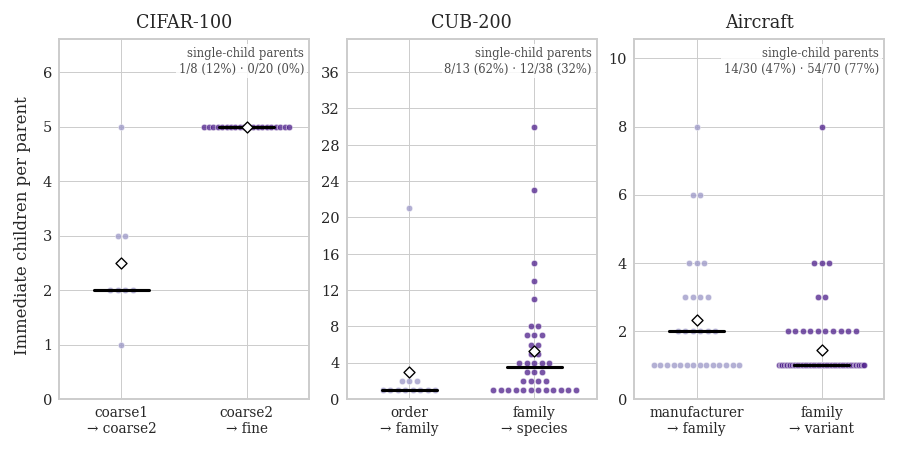

In [9]:
def symmetric_swarm_offsets(count, maximum_half_width=0.34, preferred_spacing=0.06):
    if count <= 1:
        return np.zeros(count)
    half_width = min(maximum_half_width, preferred_spacing * (count - 1) / 2)
    return np.linspace(-half_width, half_width, count)

fig, axes = plt.subplots(1, 3, figsize=(TEXT_WIDTH_IN, 3.1))
for ax, dataset_name in zip(axes, DATASET_SPECS):
    subset = branching.query('dataset == @dataset_name')
    transitions = list(subset.transition.unique())
    notes = []
    for transition_idx, transition in enumerate(transitions, start=1):
        values = subset.query('transition == @transition').children.to_numpy(dtype=int)
        frequencies = Counter(int(value) for value in values)
        for children, frequency in sorted(frequencies.items()):
            x = transition_idx + symmetric_swarm_offsets(frequency)
            ax.scatter(x, np.full(frequency, children), s=11, alpha=0.78,
                       color=TRANSITION_COLORS[transition_idx - 1],
                       edgecolor='white', linewidth=0.3, zorder=3)
        median = float(np.median(values))
        mean = float(np.mean(values))
        ax.plot([transition_idx - 0.22, transition_idx + 0.22], [median, median],
                color='black', linewidth=1.6, zorder=4)
        ax.scatter([transition_idx], [mean], marker='D', s=16, facecolor='white',
                   edgecolor='black', linewidth=0.7, zorder=5)
        singletons = int((values == 1).sum())
        notes.append(f'{singletons}/{len(values)} ({100 * singletons / len(values):.0f}%)')
        tallest = subset.children.max()
    ax.set_xticks(np.arange(1, len(transitions) + 1),
                  [t.replace(' → ', '\n→ ') for t in transitions], fontsize=7)
    ax.set_title(SHORT_NAMES[dataset_name])
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_xlim(0.5, len(transitions) + 0.5)
    ax.set_ylim(0, tallest * 1.32)
    ax.text(0.98, 0.98, 'single-child parents\n' + ' · '.join(notes), transform=ax.transAxes,
            ha='right', va='top', fontsize=6.0, color='0.3', linespacing=1.3,
            bbox={'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.85, 'pad': 1.5})

fig.supylabel('Immediate children per parent', fontsize=8.5)
save_figure(fig, 'hierarchy_branching_beeswarms')
plt.show()


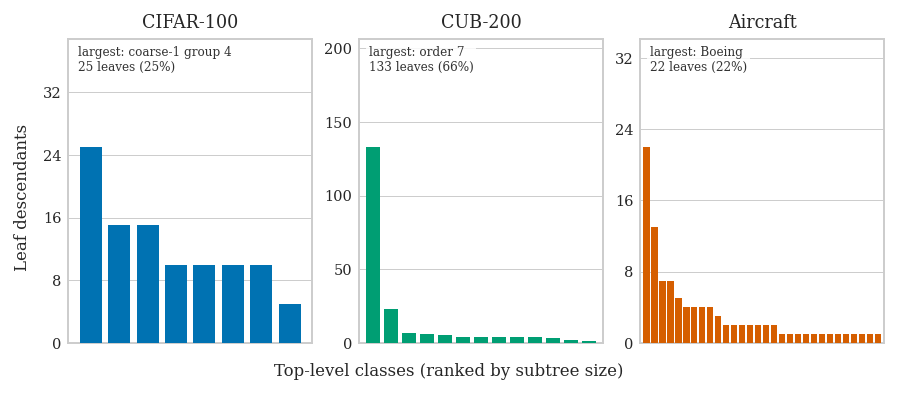

In [10]:
def root_labels(dataset_name, bundle):
    """Name every top-level class when the dataset provides one, else its raw ID."""
    train = bundle['splits']['train']
    raw_ids = train.label_space.raw_ids_per_level[0]
    if dataset_name == 'FGVC-Aircraft':
        named = {}
        for sample in train.samples:
            named.setdefault(int(sample['labels'][0]), sample['meta'].get('manufacturer_name'))
        return {root: str(named.get(root) or f'manufacturer {raw_ids[root]}') for root in range(len(raw_ids))}
    prefix = 'coarse-1 group' if dataset_name == 'CIFAR-100' else 'order'
    return {root: f'{prefix} {raw_ids[root]}' for root in range(len(raw_ids))}

descendant_rows = []
for dataset_name, bundle in datasets_by_name.items():
    taxonomy = bundle['splits']['train'].taxonomy['parent_of']
    n_root = bundle['splits']['train'].num_classes_per_level[0]
    labels = root_labels(dataset_name, bundle)
    middle_to_root = {int(child): int(parent) for child, parent in taxonomy[1].items()}
    leaf_to_middle = {int(child): int(parent) for child, parent in taxonomy[2].items()}
    counts = Counter(middle_to_root[middle] for middle in leaf_to_middle.values())
    for root_id in range(n_root):
        descendant_rows.append({'dataset': dataset_name, 'root_id': root_id,
                                'root_label': labels[root_id], 'leaf_descendants': counts[root_id]})
leaf_descendants = pd.DataFrame(descendant_rows)
leaf_descendants.to_csv(TABLE_DIR / 'leaf_descendants_per_root.csv', index=False)

fig, axes = plt.subplots(1, 3, figsize=(TEXT_WIDTH_IN, 2.7))
for ax, dataset_name in zip(axes, DATASET_SPECS):
    values = (leaf_descendants.query('dataset == @dataset_name')
              .sort_values('leaf_descendants', ascending=False).reset_index(drop=True))
    heights = values.leaf_descendants.to_numpy(dtype=float)
    ranks = np.arange(len(values))
    ax.bar(ranks, heights, color=COLORS[dataset_name], width=0.78, zorder=3)
    ax.set_title(SHORT_NAMES[dataset_name])
    ax.set_xticks([])
    ax.set_xlim(-0.8, len(values) - 0.2)
    ax.set_ylim(0, heights.max() * 1.55)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))

    share = 100.0 * heights[0] / heights.sum()
    ax.text(0.04, 0.98, f'largest: {values.root_label.iloc[0]}\n{int(heights[0])} leaves ({share:.0f}%)',
            transform=ax.transAxes, ha='left', va='top', fontsize=6.2, color='0.2', zorder=6,
            bbox={'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.85, 'pad': 1.5})

fig.supxlabel('Top-level classes (ranked by subtree size)', fontsize=8.5)
fig.supylabel('Leaf descendants', fontsize=8.5)
save_figure(fig, 'leaf_descendants_per_root')
plt.show()


### Taxonomy shape

The figure below draws the taxonomies themselves. Each panel is an icicle plot of one dataset: the three horizontal bands are the three hierarchy levels, every rectangle is one class, and its width is the fraction of leaf classes in its subtree. Children are drawn directly beneath their parent, and classes are ordered by subtree size, so the horizontal axis is a ranking of subtrees rather than a class ID. A taxonomy in which every coarse class covers a comparable number of leaves produces bands of near-equal rectangles; a wide rectangle in the top band is a coarse class that already accounts for a large part of the label space, and a rectangle whose width is unchanged from one band to the next is a single-child chain.

Widths are shares of leaf classes, not shares of images. Because leaf-class sample counts are close to uniform in all three datasets, the two readings are similar here, but they are not the same quantity.


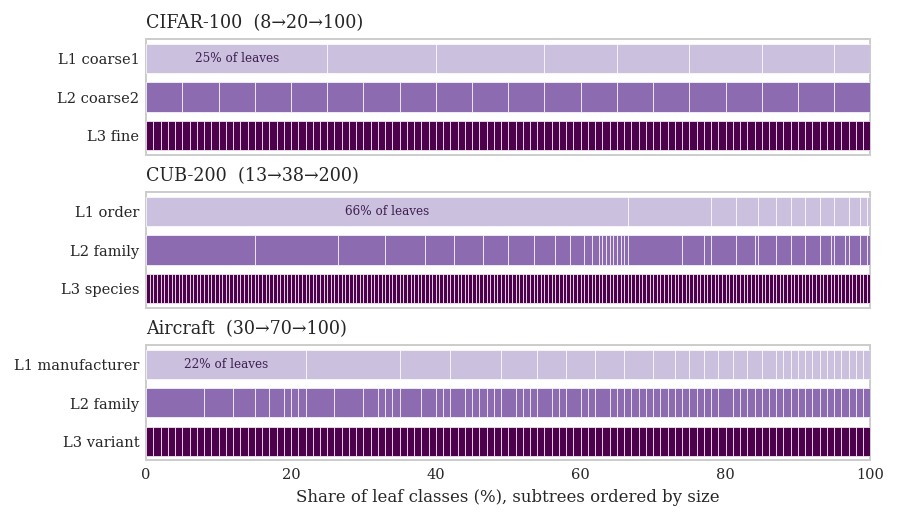

In [11]:
def icicle_layout(bundle):
    """Left-to-right span of every class, with children nested under their parent."""
    train = bundle['splits']['train']
    parent_of = train.taxonomy['parent_of']
    counts = train.num_classes_per_level
    middle_of_leaf = {int(child): int(parent) for child, parent in parent_of[2].items()}
    root_of_middle = {int(child): int(parent) for child, parent in parent_of[1].items()}
    leaves_per_middle = Counter(middle_of_leaf.values())
    leaves_per_root = Counter(root_of_middle[middle] for middle in middle_of_leaf.values())

    spans = {0: {}, 1: {}, 2: {}}
    cursor = 0.0
    for root in sorted(range(counts[0]), key=lambda node: (-leaves_per_root[node], node)):
        root_start = cursor
        middles = [node for node in range(counts[1]) if root_of_middle.get(node) == root]
        for middle in sorted(middles, key=lambda node: (-leaves_per_middle[node], node)):
            middle_start = cursor
            for leaf in sorted(node for node in range(counts[2]) if middle_of_leaf.get(node) == middle):
                spans[2][leaf] = (cursor, 1.0)
                cursor += 1.0
            spans[1][middle] = (middle_start, cursor - middle_start)
        spans[0][root] = (root_start, cursor - root_start)
    return spans, cursor

fig, axes = plt.subplots(3, 1, figsize=(TEXT_WIDTH_IN, 3.6))
for ax, (dataset_name, bundle) in zip(axes, datasets_by_name.items()):
    levels = list(bundle['cfg'].dataset.levels)
    spans, total = icicle_layout(bundle)
    for level in range(3):
        for start, width in spans[level].values():
            ax.add_patch(plt.Rectangle((100.0 * start / total, 2 - level + 0.12),
                                       100.0 * width / total, 0.76,
                                       facecolor=LEVEL_COLORS[level], edgecolor='white',
                                       linewidth=0.35, zorder=3))
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 3)
    ax.set_yticks([2.5, 1.5, 0.5], [f'L1 {levels[0]}', f'L2 {levels[1]}', f'L3 {levels[2]}'])
    ax.set_title(f'{SHORT_NAMES[dataset_name]}  ({"→".join(str(n) for n in bundle["splits"]["train"].num_classes_per_level)})',
                 loc='left')
    ax.grid(visible=False)
    ax.tick_params(axis='y', length=0)
    widest = max(spans[0].values(), key=lambda span: span[1])
    widest_share = 100.0 * widest[1] / total
    ax.text(100.0 * (widest[0] + widest[1] / 2) / total, 2.5, f'{widest_share:.0f}% of leaves',
            ha='center', va='center', fontsize=6.2, color=LEVEL_EDGE, zorder=4)
axes[-1].set_xlabel('Share of leaf classes (%), subtrees ordered by size')
for ax in axes[:-1]:
    ax.set_xticklabels([])

save_figure(fig, 'taxonomy_icicle')
plt.show()


### How much of the leaf decision does a parent already make?

The branching statistics can be summarized in one quantity per transition: the residual uncertainty about the child once the parent is known, measured in bits as the conditional entropy $H(\text{child}\mid\text{parent})$, against the $H(\text{child})=\log_2 N$ that would remain without the hierarchy. A transition where every parent has one child has zero residual uncertainty and adds no decision; a transition where all parents have the same large fan-out reduces the entropy by exactly $\log_2$ of the number of parents.

**How to read the figure.** Each pair of bars is one transition. The full bar height is how many yes/no questions it would take, on average, to identify the child class if nothing else were known; the colored part is how many are still needed once the parent is known, and the grey part above it is what the hierarchy removes. The percentage is the share removed. A worked example: on Aircraft there are 100 variants, so identifying one from scratch costs $\log_2 100 = 6.64$ bits, but knowing the family leaves only 0.78 bits — on average fewer than two equally likely variants remain, because 54 of the 70 families contain a single variant. On CUB the same transition leaves 3.10 of 7.64 bits, so the family narrows the species down to the equivalent of $2^{3.10}\approx 9$ equally likely alternatives. Shorter colored bars therefore mean a coarse label that decides more of the fine label.

Two versions are computed. The **structural** version assumes a uniform distribution over classes and therefore describes the taxonomy alone; the **empirical** version weights each class by its number of training images. They are reported side by side so that the effect of the taxonomy is not confused with the effect of sample balance.

This is a property of the label space, not a prediction about model behavior. It says how much information a correct coarse prediction supplies about the leaf, not how easily a model recovers it.


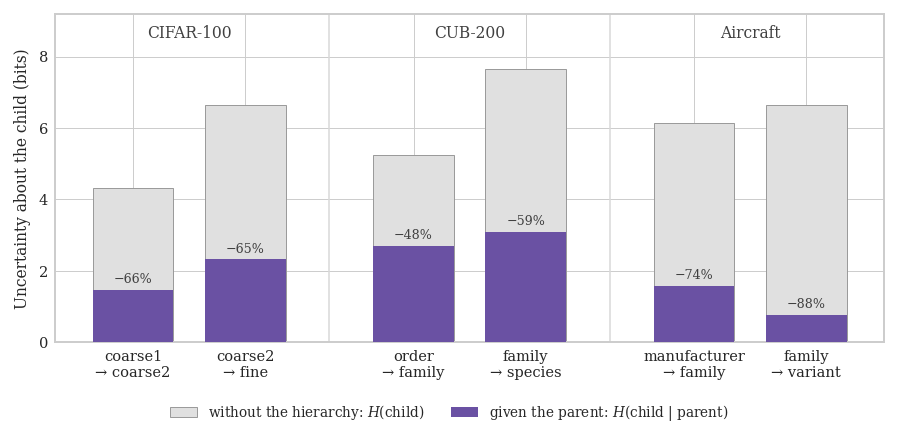

,dataset,transition,H(child) structural,H(child|parent) structural,reduction structural (%),H(child) empirical,H(child|parent) empirical,reduction empirical (%)
0,CIFAR-100,coarse1 → coarse2,4.32,1.46,66,4.32,1.46,66
1,CIFAR-100,coarse2 → fine,6.64,2.32,65,6.64,2.32,65
2,CUB-200-2011,order → family,5.25,2.71,48,4.55,2.58,43
3,CUB-200-2011,family → species,7.64,3.10,59,7.64,3.10,59
4,FGVC-Aircraft,manufacturer → family,6.13,1.57,74,5.87,1.70,71
5,FGVC-Aircraft,family → variant,6.64,0.78,88,6.64,0.77,88


In [12]:
def structural_conditional_entropy(child_counts):
    """H(child | parent) in bits with a uniform distribution over children."""
    sizes = np.asarray([count for count in child_counts if count > 0], dtype=float)
    total = sizes.sum()
    return float(np.sum(sizes / total * np.log2(sizes))), float(np.log2(total))

def empirical_conditional_entropy(dataset_name, bundle, parent_level, child_level):
    """H(child | parent) in bits weighted by training-image counts."""
    levels = list(bundle['cfg'].dataset.levels)
    frame = samples.query('dataset == @dataset_name and split == "train"')
    joint = frame.groupby([levels[parent_level], levels[child_level]]).size()
    probabilities = joint / joint.sum()
    parent_probabilities = probabilities.groupby(level=0).sum()
    conditional = probabilities / parent_probabilities.reindex(probabilities.index.get_level_values(0)).to_numpy()
    entropy = float(-np.sum(probabilities.to_numpy() * np.log2(conditional.to_numpy())))
    marginal = probabilities.groupby(level=1).sum().to_numpy()
    return entropy, float(-np.sum(marginal * np.log2(marginal)))

entropy_rows = []
for dataset_name, bundle in datasets_by_name.items():
    subset = branching.query('dataset == @dataset_name')
    for child_level, transition in enumerate(subset.transition.unique(), start=1):
        counts = subset.query('transition == @transition').children.to_numpy(dtype=int)
        residual, unconditional = structural_conditional_entropy(counts)
        empirical_residual, empirical_unconditional = empirical_conditional_entropy(
            dataset_name, bundle, child_level - 1, child_level)
        entropy_rows.append({
            'dataset': dataset_name, 'transition': transition,
            'H(child) structural': unconditional, 'H(child|parent) structural': residual,
            'reduction structural (%)': 100.0 * (1.0 - residual / unconditional),
            'H(child) empirical': empirical_unconditional,
            'H(child|parent) empirical': empirical_residual,
            'reduction empirical (%)': 100.0 * (1.0 - empirical_residual / empirical_unconditional),
        })
hierarchy_information = pd.DataFrame(entropy_rows)
hierarchy_information.to_csv(TABLE_DIR / 'hierarchy_conditional_entropy.csv', index=False)

fig, ax = plt.subplots(figsize=(TEXT_WIDTH_IN, 3.0))
positions, centres = [], []
position = 0.0
for dataset_index, dataset_name in enumerate(DATASET_SPECS):
    rows = hierarchy_information.query('dataset == @dataset_name').to_dict('records')
    first = position
    for transition_index, row in enumerate(rows):
        ax.bar(position, row['H(child) structural'], width=0.72, color='0.88', edgecolor='0.6',
               linewidth=0.5, zorder=2,
               label='without the hierarchy: $H$(child)' if position == 0 else None)
        ax.bar(position, row['H(child|parent) structural'], width=0.72,
               color='#6A51A3', zorder=3,
               label='given the parent: $H$(child $|$ parent)' if position == 0 else None)
        ax.text(position, row['H(child|parent) structural'] + 0.12,
                f"−{row['reduction structural (%)']:.0f}%", ha='center', va='bottom',
                fontsize=6.5, color='0.25')
        positions.append((position, row['transition'].replace(' → ', '\n→ ')))
        position += 1.0
    centres.append((first + position - 1.0) / 2.0)
    if dataset_index < len(DATASET_SPECS) - 1:
        ax.axvline(position - 0.25, color='0.85', linewidth=0.8, zorder=1)
        position += 0.5

ax.set_xticks([p for p, _ in positions], [label for _, label in positions])
ax.set_ylabel('Uncertainty about the child (bits)', fontsize=8)
ax.set_ylim(0, 9.2)
handles, legend_labels = ax.get_legend_handles_labels()
fig.legend(handles, legend_labels, loc='outside lower center', ncol=2, frameon=False)
for centre, dataset_name in zip(centres, DATASET_SPECS):
    ax.text(centre, 8.9, SHORT_NAMES[dataset_name], ha='center', va='top', fontsize=8, color='0.25')
save_figure(fig, 'hierarchy_conditional_entropy')
plt.show()

display(hierarchy_information.style.format({
    column: '{:.2f}' for column in hierarchy_information.columns if column.startswith('H(')
} | {column: '{:.0f}' for column in hierarchy_information.columns if column.startswith('reduction')}))


## Image geometry

Resolution and aspect ratio characterize the visual input before model-specific resizing or cropping. CIFAR-100 is a fixed 32×32 low-resolution benchmark; CUB and Aircraft contain higher-resolution photographs with variable geometry. The scan is deterministic and reports its sample size, so the resulting estimates are auditable.

**How to read the geometry figure.** Every translucent point is one sampled training image: horizontal position is native width and vertical position is native height. Both axes are logarithmic, so equal visual distances represent equal multiplicative changes rather than equal pixel increments. The dashed diagonal marks square images; points above it are portrait and points below it are landscape. The small open square is the 224×224 input of the model presets, which makes the relevant asymmetry explicit: CIFAR-100 is *upsampled* by a factor of seven per side, whereas CUB and Aircraft are downsampled, Aircraft by up to an order of magnitude in area.

Two features of the plot are properties of the distributions rather than of the photographs, and should be stated in the caption so that they are not read as structure in the data. All CIFAR-100 points coincide in the single marker at 32×32, because the benchmark is fixed-resolution. The right-angled edge at the top right of the CUB cloud is the 500-pixel cap on the long side of every CUB image: in the sample, no CUB image exceeds 500 px in either dimension.

Orientation is not plotted separately: the median aspect ratios in the table above (1.00 for CIFAR-100, 1.33 for CUB, 1.47 for Aircraft) already summarize it, and the same information is visible in this figure as distance from the diagonal.


In [13]:
def deterministic_indices(length, maximum, seed):
    if length <= maximum:
        return np.arange(length)
    return np.sort(np.random.default_rng(seed).choice(length, size=maximum, replace=False))

geometry_rows = []
for dataset_idx, (dataset_name, bundle) in enumerate(datasets_by_name.items()):
    for split_idx, (split, dataset) in enumerate(bundle['splits'].items()):
        indices = deterministic_indices(len(dataset), MAX_IMAGES_PER_SPLIT, RANDOM_SEED + 10 * dataset_idx + split_idx)
        for index in indices:
            image = dataset._load_image(dataset.samples[int(index)]['image'])
            width, height = image.size
            geometry_rows.append({
                'dataset': dataset_name, 'split': split, 'width': width, 'height': height,
                'megapixels': width * height / 1_000_000, 'aspect_ratio': width / height,
            })
            image.close()
image_geometry = pd.DataFrame(geometry_rows)
image_geometry.to_csv(TABLE_DIR / 'sampled_image_geometry.csv', index=False)

geometry_summary = (image_geometry.groupby(['dataset', 'split'])
    .agg(images_scanned=('width', 'size'), width_median=('width', 'median'), height_median=('height', 'median'),
         megapixels_median=('megapixels', 'median'), megapixels_min=('megapixels', 'min'),
         megapixels_max=('megapixels', 'max'), aspect_ratio_median=('aspect_ratio', 'median'))
    .reset_index())
geometry_summary.to_csv(TABLE_DIR / 'image_geometry_summary.csv', index=False)
display(geometry_summary.style.format({
    'width_median': '{:.0f}', 'height_median': '{:.0f}', 'megapixels_median': '{:.3f}',
    'megapixels_min': '{:.3f}', 'megapixels_max': '{:.3f}', 'aspect_ratio_median': '{:.2f}',
}))


,dataset,split,images_scanned,width_median,height_median,megapixels_median,megapixels_min,megapixels_max,aspect_ratio_median
0,CIFAR-100,test,2000,32,32,0.001,0.001,0.001,1.00
1,CIFAR-100,train,2000,32,32,0.001,0.001,0.001,1.00
2,CIFAR-100,val,2000,32,32,0.001,0.001,0.001,1.00
3,CUB-200-2011,test,2000,500,374,0.178,0.022,0.250,1.33
4,CUB-200-2011,train,2000,500,375,0.178,0.019,0.250,1.33
5,CUB-200-2011,val,800,500,372,0.178,0.020,0.250,1.33
6,FGVC-Aircraft,test,2000,1024,697,0.714,0.330,1.915,1.47
7,FGVC-Aircraft,train,2000,1024,699,0.716,0.350,1.901,1.47
8,FGVC-Aircraft,val,2000,1024,697,0.715,0.333,1.928,1.47


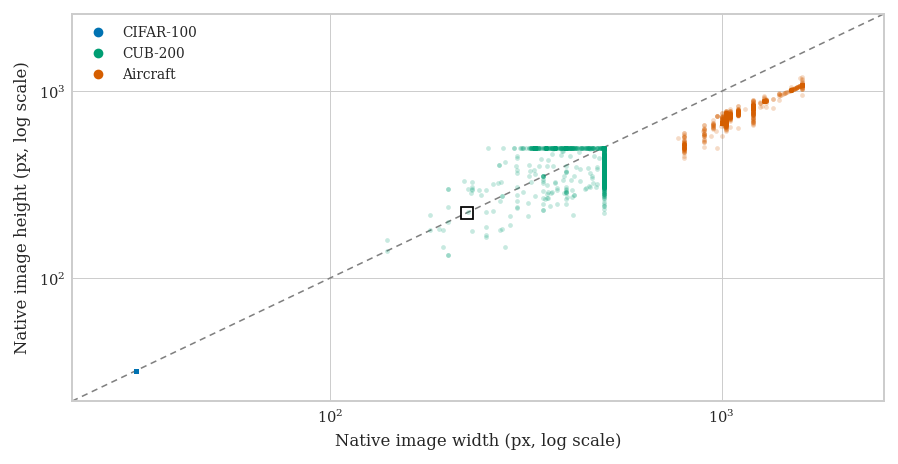

In [14]:
fig, ax_pixels = plt.subplots(figsize=(TEXT_WIDTH_IN, 3.2))
for dataset_name in DATASET_SPECS:
    values = image_geometry.query("dataset == @dataset_name and split == 'train'")
    ax_pixels.scatter(values.width, values.height, s=6, alpha=0.22, linewidths=0,
                      color=COLORS[dataset_name], zorder=3)

limits = (22, 2_600)
# Square-image diagonal and the 224 px preset input; both are explained in the
# surrounding text rather than annotated inside the axes.
ax_pixels.plot(limits, limits, color='0.5', linestyle=(0, (4, 3)), linewidth=0.8, zorder=2)
ax_pixels.plot([MODEL_INPUT_PX], [MODEL_INPUT_PX], marker='s', markersize=6, markerfacecolor='none',
               markeredgecolor='black', markeredgewidth=0.9, zorder=5)
ax_pixels.set_xscale('log')
ax_pixels.set_yscale('log')
ax_pixels.set_xlim(*limits)
ax_pixels.set_ylim(*limits)
ax_pixels.set_xlabel('Native image width (px, log scale)')
ax_pixels.set_ylabel('Native image height (px, log scale)')
ax_pixels.legend(handles=[Line2D([], [], marker='o', linestyle='', markersize=4,
                                 color=COLORS[name], label=SHORT_NAMES[name]) for name in DATASET_SPECS],
                 loc='upper left', framealpha=0.9)

save_figure(fig, 'native_image_geometry')
plt.show()


## Representative images

The gallery samples distinct leaf classes from the training split using a fixed seed. It is intended to illustrate the difference between object-centric 32×32 images, fine-grained bird recognition, and fine-grained aircraft recognition—not to establish quantitative difficulty. Each row corresponds to one dataset and each column is an independently selected leaf class; column positions do not represent matched concepts across datasets. The title above each image is its leaf-class name. This figure is exported as PNG only: embedding eighteen full-resolution photographs in a vector PDF produces a very large file with no benefit, since the content is raster.


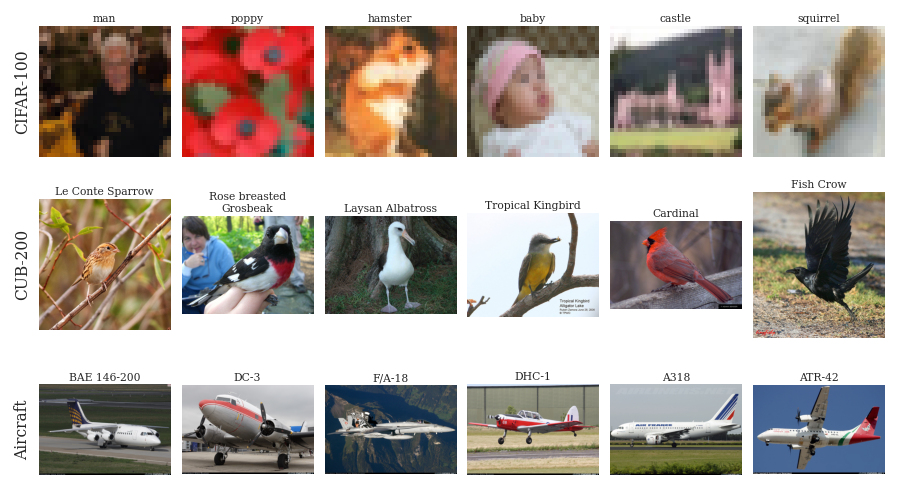

In [15]:
def leaf_name(dataset_name, dataset, sample):
    leaf_id = int(sample['labels'][-1])
    if dataset_name == 'CIFAR-100':
        meta_path = Path(dataset.root) / 'cifar-100-python' / 'meta'
        if not meta_path.exists():
            meta_path = Path(dataset.root) / 'meta'
        if meta_path.exists():
            with meta_path.open('rb') as handle:
                payload = pickle.load(handle, encoding='latin1')
            names = payload.get('fine_label_names', payload.get(b'fine_label_names'))
            if names:
                value = names[leaf_id]
                return value.decode() if isinstance(value, bytes) else str(value)
    if dataset_name == 'CUB-200-2011':
        candidates = [Path(dataset.root) / 'classes.txt', Path(dataset.root) / 'CUB_200_2011' / 'classes.txt']
        path = next((p for p in candidates if p.exists()), None)
        if path:
            rows = [line.strip().split(maxsplit=1)[1] for line in path.read_text(encoding='utf-8').splitlines() if line.strip()]
            return rows[leaf_id].split('.', 1)[-1].replace('_', ' ')
    if dataset_name == 'FGVC-Aircraft':
        return str(sample['meta'].get('variant_name', f'variant {leaf_id}'))
    return f'leaf {leaf_id}'

N_EXAMPLES = 6
fig, axes = plt.subplots(3, N_EXAMPLES, figsize=(TEXT_WIDTH_IN, 3.6))
for row, (dataset_name, bundle) in enumerate(datasets_by_name.items()):
    dataset = bundle['splits']['train']
    by_leaf = {}
    for index, sample in enumerate(dataset.samples):
        by_leaf.setdefault(int(sample['labels'][-1]), index)
    leaves = np.array(sorted(by_leaf))
    chosen = np.random.default_rng(RANDOM_SEED + row).choice(leaves, size=N_EXAMPLES, replace=False)
    for col, leaf in enumerate(chosen):
        ax = axes[row, col]
        sample = dataset.samples[by_leaf[int(leaf)]]
        image = dataset._load_image(sample['image'])
        ax.imshow(image)
        ax.set_title(textwrap.fill(leaf_name(dataset_name, dataset, sample), 18), fontsize=5.5, pad=2.0)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.grid(visible=False)
        for spine in ax.spines.values():
            spine.set_visible(False)
        image.close()
    # Keep the frame of the first column alive so that its y-label can carry the dataset name.
    axes[row, 0].set_ylabel(SHORT_NAMES[dataset_name], fontsize=8)

save_figure(fig, 'representative_dataset_images', formats=('png',))
plt.show()


## Automatically generated thesis-ready observations

The statements below are generated from the current data and configuration rather than hard-coded. They are suitable starting points for the datasets subsection, but causal claims about model performance require the experiment results and should not be inferred from descriptive statistics alone.


In [16]:
insights = []
for dataset_name, bundle in datasets_by_name.items():
    levels = list(bundle['cfg'].dataset.levels)
    counts = bundle['splits']['train'].num_classes_per_level
    split_sizes = {split: len(ds) for split, ds in bundle['splits'].items()}
    train_balance = balance_summary.query("dataset == @dataset_name and split == 'train'").iloc[0]
    roots = leaf_descendants.query('dataset == @dataset_name')
    geom = geometry_summary.query("dataset == @dataset_name and split == 'train'").iloc[0]
    fanout = branching.query('dataset == @dataset_name')
    singletons = ', '.join(
        f'{transition.replace(" → ", "→")} {int((group.children == 1).sum())}/{len(group)}'
        for transition, group in fanout.groupby('transition', sort=False)
    )
    leaf_transition = hierarchy_information.query('dataset == @dataset_name').iloc[-1]
    top_root = roots.sort_values('leaf_descendants', ascending=False).iloc[0]
    insights.append(
        f"**{dataset_name}.** The protocol uses {split_sizes['train']:,} training, {split_sizes['val']:,} validation, "
        f"and {split_sizes['test']:,} test images with a {counts[0]}→{counts[1]}→{counts[2]} "
        f"{levels[0]}→{levels[1]}→{levels[2]} hierarchy. Training leaf classes contain "
        f"{int(train_balance['minimum'])}–{int(train_balance['maximum'])} images (Gini {train_balance['gini']:.3f}). "
        f"The largest top-level class ({top_root['root_label']}) covers {int(top_root['leaf_descendants'])} of "
        f"{counts[-1]} leaf classes ({100 * top_root['leaf_descendants'] / counts[-1]:.0f}%), and the taxonomy contains "
        f"single-child parents at {singletons}. Knowing the middle-level label leaves "
        f"{leaf_transition['H(child|parent) structural']:.2f} bits of structural uncertainty about the leaf, "
        f"against {leaf_transition['H(child) structural']:.2f} bits without the hierarchy "
        f"({leaf_transition['reduction structural (%)']:.0f}% reduction). "
        f"The sampled native training images have median geometry {geom['width_median']:.0f}×{geom['height_median']:.0f} pixels "
        f"and median aspect ratio {geom['aspect_ratio_median']:.2f}."
    )

provenance_lines = [f"- **{name}:** {spec['provenance']}." for name, spec in DATASET_SPECS.items()]
display(Markdown('\n\n'.join(insights) + '\n\n**Taxonomy provenance**\n\n' + '\n'.join(provenance_lines)))


**CIFAR-100.** The protocol uses 45,000 training, 5,000 validation, and 10,000 test images with a 8→20→100 coarse1→coarse2→fine hierarchy. Training leaf classes contain 450–450 images (Gini 0.000). The largest top-level class (coarse-1 group 4) covers 25 of 100 leaf classes (25%), and the taxonomy contains single-child parents at coarse1→coarse2 1/8, coarse2→fine 0/20. Knowing the middle-level label leaves 2.32 bits of structural uncertainty about the leaf, against 6.64 bits without the hierarchy (65% reduction). The sampled native training images have median geometry 32×32 pixels and median aspect ratio 1.00.

**CUB-200-2011.** The protocol uses 5,194 training, 800 validation, and 5,794 test images with a 13→38→200 order→family→species hierarchy. Training leaf classes contain 25–26 images (Gini 0.001). The largest top-level class (order 7) covers 133 of 200 leaf classes (66%), and the taxonomy contains single-child parents at order→family 8/13, family→species 12/38. Knowing the middle-level label leaves 3.10 bits of structural uncertainty about the leaf, against 7.64 bits without the hierarchy (59% reduction). The sampled native training images have median geometry 500×375 pixels and median aspect ratio 1.33.

**FGVC-Aircraft.** The protocol uses 3,334 training, 3,333 validation, and 3,333 test images with a 30→70→100 manufacturer→family→variant hierarchy. Training leaf classes contain 33–34 images (Gini 0.007). The largest top-level class (Boeing) covers 22 of 100 leaf classes (22%), and the taxonomy contains single-child parents at manufacturer→family 14/30, family→variant 54/70. Knowing the middle-level label leaves 0.78 bits of structural uncertainty about the leaf, against 6.64 bits without the hierarchy (88% reduction). The sampled native training images have median geometry 1024×699 pixels and median aspect ratio 1.47.

**Taxonomy provenance**

- **CIFAR-100:** official fine/coarse labels + published B-CNN upper edge.
- **CUB-200-2011:** official images/split + order/family mapping retained from H-CAST.
- **FGVC-Aircraft:** official parallel manufacturer/family/variant annotations.

## Interpretation guide and limitations

- The three datasets share a depth of three for experimental comparability, but their semantic levels and construction procedures differ. A level index should not be interpreted as equal semantic difficulty across datasets.
- Near-uniform leaf sample counts do not imply a balanced taxonomy. Unequal branching changes the number of descendants represented by a coarse decision and can influence hierarchy-aware metrics.
- Conditional entropy and single-child-parent counts are properties of the label space computed from the taxonomy and the training labels. They quantify how much a correct parent prediction constrains the leaf; they do not predict accuracy, and they say nothing about whether a model can exploit that constraint.
- The validation splits for CIFAR-100 and CUB are deterministic, leaf-stratified subsets of their original training pools. Aircraft uses the official train, validation, and test partitions, which allocate a much larger share to validation; split composition is therefore not comparable across datasets.
- Native image geometry describes the source data, not the tensors seen by every model. Model presets use different resize/crop pipelines and, in some cases, different input resolutions, so the 224×224 reference marker is indicative rather than exact.
- Representative images are qualitative examples. They do not measure visual diversity, inter-class similarity, background bias, or intrinsic classification difficulty.
- The CUB order/family mapping is inherited from H-CAST, while the CIFAR upper edge is externally imposed. Results therefore apply to the explicit taxonomies used here and should not be generalized to every possible hierarchy for the same images.
- Figures are authored at the printed text width (6.3 in) so that they can be included without scaling. Rescaling them in LaTeX changes the effective font size and breaks consistency with the body text.


In [17]:
exported = sorted([*FIGURE_DIR.glob('*'), *TABLE_DIR.glob('*')])
print(f'Exported {len(exported)} artifacts to {OUTPUT_DIR}:')
for path in exported:
    print(f'  - {path.relative_to(OUTPUT_DIR)}')


Exported 40 artifacts to /scratch/g.saggini1/outputs/analysis/datasets:
  - figures/dataset_scale_and_taxonomy_width.pdf
  - figures/dataset_scale_and_taxonomy_width.png
  - figures/hierarchy_branching_beeswarms.pdf
  - figures/hierarchy_branching_beeswarms.png
  - figures/hierarchy_branching_factors.pdf
  - figures/hierarchy_branching_factors.png
  - figures/hierarchy_branching_frequency_bars.pdf
  - figures/hierarchy_branching_frequency_bars.png
  - figures/hierarchy_branching_frequency_heatmap.pdf
  - figures/hierarchy_branching_frequency_heatmap.png
  - figures/hierarchy_branching_stacked_dots.pdf
  - figures/hierarchy_branching_stacked_dots.png
  - figures/hierarchy_branching_violins.pdf
  - figures/hierarchy_branching_violins.png
  - figures/hierarchy_conditional_entropy.pdf
  - figures/hierarchy_conditional_entropy.png
  - figures/hierarchy_fanout_distribution.pdf
  - figures/hierarchy_fanout_distribution.png
  - figures/leaf_class_balance.pdf
  - figures/leaf_class_balance.png
